In [6]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
import tensorflow as tf
import random as rn
from sklearn.metrics import accuracy_score, precision_score, recall_score, log_loss,f1_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import pywt
from skimage.transform import resize
from scipy import signal

# Reproducibility
sd = 1
os.environ['PYTHONHASHSEED'] = str(sd)
np.random.seed(sd)
rn.seed(sd)
tf.random.set_seed(sd)

# Root directory containing data folders
root_dir = './Paderborn_PreCase1_Data'

# Class label structure
data_structure = {
    0: ("Healthy", ["K001", "K002", "K003", "K004", "K005"]),
    1: ("OR_Damage", ["KA04", "KA15", "KA16", "KA22", "KA30"]),
    2: ("IR_Damage", ["KI04", "KI14", "KI16", "KI18", "KI21"]),
}

sample_limit_per_label = {0: 256000, 1: 5120, 2: 5120}

# Extract vibration signal from .mat file
def extract_signals_df(filepath, signal="vibration"):
    signals = {"vibration": 6, "current_1": 1, "current_2": 2}
    mat = loadmat(filepath, struct_as_record=False, squeeze_me=True)
    field = next(k for k in mat if not k.startswith("__"))
    struct = mat[field]
    X_channels = struct.X
    Y_channels = struct.Y
    v = Y_channels[signals["vibration"]].Data.flatten().reshape(-1, 1)
    return pd.DataFrame(v, columns=["vibration"])

# Data extraction
all_data = {0: [], 1: [], 2: []}

for label, (category, folders) in data_structure.items():
    for folder in folders:
        folder_path = os.path.join(root_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} not found.")
            continue

        mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]
        if not mat_files:
            print(f"No .mat files found in {folder_path}")
            continue

        filename = mat_files[0]
        file_path = os.path.join(folder_path, filename)
        try:
            df = extract_signals_df(file_path, signal="vibration")
            df = df.iloc[:sample_limit_per_label[label]].copy()
            df["label"] = label
            all_data[label].append(df)
            print(f"Loaded {file_path} with {len(df)} samples.")
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# Combine all data
final_df = pd.concat([df for dfs in all_data.values() for df in dfs], ignore_index=True)
final_df.rename(columns={"vibration": "signal"}, inplace=True)
print("\nCombined data shape:", final_df.shape)
print(final_df.head())

# Signal grouping
df_signals = final_df[["signal", "label"]].copy()
grouped_signals = [
    df_signals[df_signals['label'] == i]['signal'].values.astype(float)
    for i in sorted(df_signals['label'].unique())
]



# Datapoints per group
# print("\n Count of samples in each group")
for idx, signal_array in enumerate(grouped_signals):
    class_name = data_structure[idx][0]
    print(f"Class {idx} ({class_name}) - Number of samples: {len(signal_array)}")


Loaded ./Paderborn_PreCase1_Data/K001/N15_M07_F04_K001_13.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K002/N09_M07_F10_K002_2.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K003/N09_M07_F10_K003_1.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K004/N09_M07_F10_K004_2.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K005/N09_M07_F10_K005_1.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/KA04/N09_M07_F10_KA04_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA15/N09_M07_F10_KA15_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA16/N09_M07_F10_KA16_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA22/N09_M07_F10_KA22_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA30/N09_M07_F10_KA30_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KI04/N09_M07_F10_KI04_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KI14/N09_M07_F10_KI14_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_D

In [7]:

# Data preparation
def Sampling(Data, interval_length, samples_per_block, ignore_points=0):
    adjusted_length = len(Data) - 2 * ignore_points
    No_of_blocks = (
        round(adjusted_length / interval_length)
        - round(samples_per_block / interval_length)
        - 1
    )
    if No_of_blocks <= 0:
        return np.empty((0, samples_per_block))
    SplitData = np.zeros([No_of_blocks, samples_per_block])
    for i in range(No_of_blocks):
        start_idx = ignore_points + i * interval_length
        SplitData[i, :] = Data[start_idx : start_idx + samples_per_block].T
    return SplitData

def DataPreparation(DataList, interval_length, samples_per_block):
    segment_list = []
    one_hot_labels = []
    integer_labels = []
    for count, signal in enumerate(DataList):
        SplitData = Sampling(signal, interval_length, samples_per_block)
        segments = SplitData.shape[0]
        
        print(f"\nClass: {count} Fault Label: {data_structure[count][0]}")
        print(f"Segments: {segments} segments")
        print(f"Sample data (first 5 elements): {SplitData[0][:5] if segments > 0 else 'Empty'}")
        
        
        if SplitData.shape[0] == 0:
            continue
        segment_list.append(SplitData)

        one_hot = np.zeros((segments, len(DataList)))
        one_hot[:, count] = 1
        one_hot_labels.append(one_hot)

        int_labels = np.full((segments, 1), count)
        integer_labels.append(int_labels)
        
        y = np.zeros([len(SplitData), len(DataList)])
        y[:, count] = 1
        y1 = np.zeros([len(SplitData), 1])
        y1[:, 0] = count
        if count == 0:
            X = SplitData
            LabelPositional = y
            Label = y1
        else:
            X = np.append(X, SplitData, axis=0)
            LabelPositional = np.append(LabelPositional, y, axis=0)
            Label = np.append(Label, y1, axis=0)
    # return X, LabelPositional, Label
    return segment_list, one_hot_labels, integer_labels

# Run preparation
# X_train, y_train_positional, y_train = DataPreparation(grouped_signals, interval_length, samples_per_block)



In [8]:
def min_max_norm(ary):
    ary = (ary - ary.min()) / np.abs(ary.max() - ary.min())
    return ary

def generate_spectrogram(segment, image_shape, fs=48000):
    f, t, spectrogram = signal.spectrogram(
        segment,
        fs,
        nperseg=256,
        # noverlap=128,
        window='hann'
    )
    spectrogram = min_max_norm(spectrogram)
    spectrogram = resize(spectrogram, image_shape, mode='constant', anti_aliasing=True)
    return spectrogram

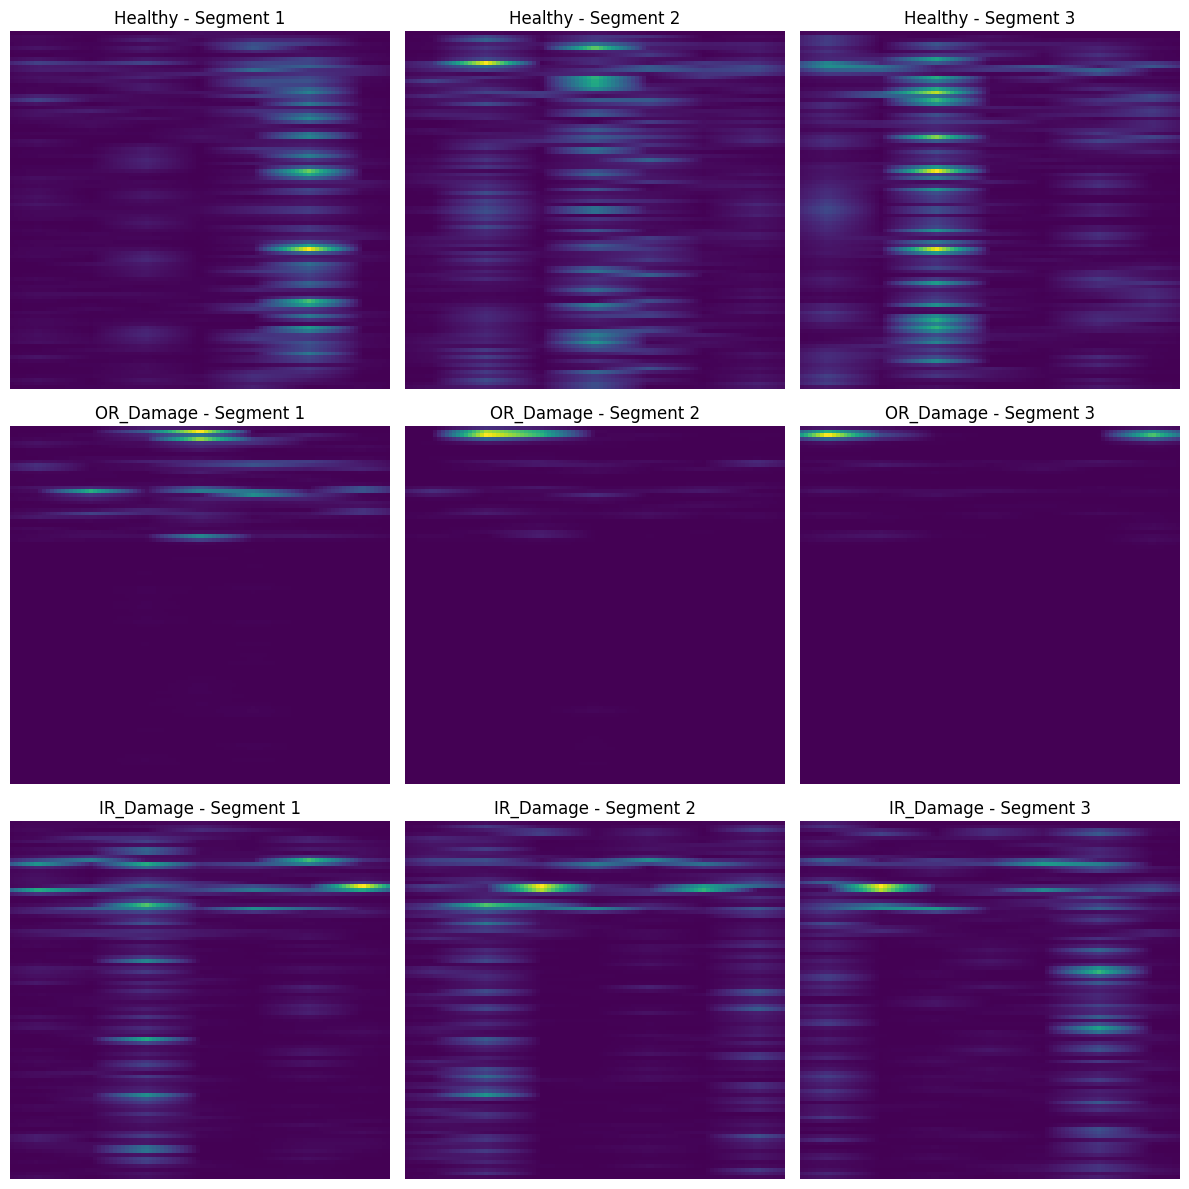

In [9]:

def plot_scalogram_grid(scalograms, titles, n_cols=3):
    n_rows = int(np.ceil(len(scalograms) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    for idx, (scalogram, title) in enumerate(zip(scalograms, titles)):
        axes[idx].imshow(scalogram, aspect='auto', cmap='viridis')
        axes[idx].set_title(title)
        axes[idx].axis('off')
    for j in range(idx + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

# Parameters
image_shape = (96, 96)
samples_per_block = 1600
interval_length = 290
num_samples_per_class = 3

# Sampling function
def Sampling(Data, interval_length, samples_per_block, ignore_points=0):
    adjusted_length = len(Data) - 2 * ignore_points
    No_of_blocks = (
        round(adjusted_length / interval_length)
        - round(samples_per_block / interval_length)
        - 1
    )
    if No_of_blocks <= 0:
        return np.empty((0, samples_per_block))
    SplitData = np.zeros([No_of_blocks, samples_per_block])
    for i in range(No_of_blocks):
        start_idx = ignore_points + i * interval_length
        SplitData[i, :] = Data[start_idx : start_idx + samples_per_block].T
    return SplitData

# Generate scalograms for each class
spectrograms_to_plot = []
titles = []
for class_idx, signal_array in enumerate(grouped_signals[:3]):  # Only classes 0 to 2
    class_name = data_structure[class_idx][0]
    sampled_segments = Sampling(signal_array, interval_length, samples_per_block)
    for i in range(min(num_samples_per_class, len(sampled_segments))):
        spectrogram = generate_spectrogram(sampled_segments[i], image_shape=image_shape)
        spectrograms_to_plot.append(spectrogram)
        titles.append(f"{class_name} - Segment {i+1}")

# Plot
plot_scalogram_grid(spectrograms_to_plot, titles)

In [10]:

# Updated per-file DataPreparation with time-based split
def process_each_mat_file_separately(data_structure, root_dir, interval_length, samples_per_block, train_ratio, sample_limit_per_label,image_shape):
    all_train_segments, all_test_segments = [], []
    all_train_labels_positional, all_test_labels_positional = [], []
    all_train_labels, all_test_labels = [], []
    segment_counts = {0: 0, 1: 0, 2: 0}
   
    
    for label, (label_name, folders) in data_structure.items():
        for folder in folders:
            folder_path = os.path.join(root_dir, folder)
            mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]
            if not mat_files:
                continue
            mat_path = os.path.join(folder_path, mat_files[0])
            df = extract_signals_df(mat_path)
            df = df.iloc[:sample_limit_per_label[label]].copy()
            signal = df["vibration"].values.flatten()

            # Sampling
            segments = Sampling(signal, interval_length, samples_per_block)

            spectrograms = np.array([generate_spectrogram(seg, image_shape, fs=48000) for seg in segments])
            
            segment_counts[label] += segments.shape[0]
            if segments.shape[0] == 0:
                continue
            n_segments = segments.shape[0]
            split_idx = int(n_segments * train_ratio)

            train_segments = spectrograms[:split_idx]
            test_segments = spectrograms[split_idx:]

            y_train_pos = np.zeros((train_segments.shape[0], len(data_structure)))
            y_train_pos[:, label] = 1
            y_train = np.full((train_segments.shape[0], 1), label)

            y_test_pos = np.zeros((test_segments.shape[0], len(data_structure)))
            y_test_pos[:, label] = 1
            y_test = np.full((test_segments.shape[0], 1), label)

            all_train_segments.append(train_segments)
            all_test_segments.append(test_segments)
            all_train_labels_positional.append(y_train_pos)
            all_test_labels_positional.append(y_test_pos)
            all_train_labels.append(y_train)
            all_test_labels.append(y_test)

    print("\nSegmented dataset shape:")
    for label in sorted(segment_counts.keys()):
        fault_label = data_structure[label][0]
        print(f"Class: {label} Fault Label: {fault_label} Segments: {segment_counts[label]} segments")
        
    # Final combine
    X_train = np.vstack(all_train_segments).reshape([-1, *image_shape, 1])
    X_test = np.vstack(all_test_segments).reshape([-1, *image_shape, 1])
    Y_train = np.vstack(all_train_labels_positional)
    Y_test = np.vstack(all_test_labels_positional)
    y_train = np.vstack(all_train_labels)
    y_test = np.vstack(all_test_labels)

    return X_train, X_test, Y_train, Y_test, y_train, y_test


In [11]:
# Split into training and test sets (80% train, 20% test)
# X_train_split, X_test_split, y_train_positional_split, y_test_positional_split = train_test_split(
#     X_train, y_train_positional, test_size=0.2, random_state=sd, stratify=y_train)

train_ratio = 0.8
n_classes = 3

# Parameters
interval_length = 320
samples_per_block = 1600
n_classes = 3  # Healthy, OR, IR
image_shape=(96, 96)

X_train_split, X_test_split, y_train_positional_split, y_test_positional_split, y_label_train, y_label_test = process_each_mat_file_separately(
    data_structure, root_dir, interval_length, samples_per_block, train_ratio=0.8, sample_limit_per_label=sample_limit_per_label, image_shape=image_shape
)

input_shape = (96, 96, 1)   # Reshaped input for CNN 2D
# print(f"\nInput Shape: {input_shape}")

# Convert one-hot labels to class indices
y_train_labels = np.argmax(y_train_positional_split, axis=1)
y_test_labels = np.argmax(y_test_positional_split, axis=1)

# Count samples per class
unique_train, counts_train = np.unique(y_label_train, return_counts=True)
unique_test, counts_test = np.unique(y_label_test, return_counts=True)

print("\nClass distribution in training set:")
for label, count in zip(unique_train, counts_train):
    print(f"Class {label}: {count} samples")

print("\nClass distribution in test set:")
for label, count in zip(unique_test, counts_test):
    print(f"Class {label}: {count} samples")

print("Train label distribution:", np.bincount(y_label_train.flatten().astype(int)))
print("Test label distribution:", np.bincount(y_label_test.flatten().astype(int)))

# Reshape data to 2D for CNN input
X_2D_train = X_train_split
X_2D_test = X_test_split

print(f"\nX_2D_train shape: {X_2D_train.shape}")
print(f"Y_train shape: {y_train_positional_split.shape}")
print(f"X_2D_test shape: {X_2D_test.shape}")
print(f"Y_test shape: {y_test_positional_split.shape}")



Segmented dataset shape:
Class: 0 Fault Label: Healthy Segments: 3970 segments
Class: 1 Fault Label: OR_Damage Segments: 50 segments
Class: 2 Fault Label: IR_Damage Segments: 50 segments

Class distribution in training set:
Class 0: 3175 samples
Class 1: 40 samples
Class 2: 40 samples

Class distribution in test set:
Class 0: 795 samples
Class 1: 10 samples
Class 2: 10 samples
Train label distribution: [3175   40   40]
Test label distribution: [795  10  10]

X_2D_train shape: (3255, 96, 96, 1)
Y_train shape: (3255, 3)
X_2D_test shape: (815, 96, 96, 1)
Y_test shape: (815, 3)


In [12]:
class CNN_2D():
    def __init__(self):
        self.model = self.CreateModel()
        self.model.summary()

    def CreateModel(self):
        model = models.Sequential([
            layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', activation='relu', input_shape=input_shape),
            layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', activation='relu', input_shape=input_shape),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            layers.Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),

            layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            layers.Conv2D(filters=128, kernel_size=(3,3), strides=1, padding ='same', activation='relu'),
            layers.Conv2D(filters=128, kernel_size=(3,3), strides=1, padding ='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),

            # layers.Flatten(),
            # layers.Dense(100,activation='relu'),
            # layers.Dense(50,activation='relu'),
            # layers.Dense(3, activation='softmax')

            layers.GlobalAveragePooling2D(),
            layers.Dense(96, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(3, activation='softmax')

            # Flatten(),  # Output: (None, 5 * 5 * 128) = (None, 3200)
            # Dense(128, activation='relu'),  # Accepts 3200 units
            # Dropout(0.5),
            # Dense(10, activation='softmax')  # 10 classes

            
        ])

        # Optimizer with a slightly higher learning rate
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss=tf.keras.losses.CategoricalCrossentropy(),
                      # loss = focal_loss(),
                      metrics=['accuracy'])
        return model

In [13]:
# Flatten the integer labels for compute_class_weight
y_train_flat = y_label_train.flatten()  # Shape: (3326,)
from sklearn.utils.class_weight import compute_class_weight
# Compute weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_flat),
    y=y_train_flat
)

# Convert to dictionary {class_idx: weight}
class_weights = dict(enumerate(class_weights_array))

print("Class weights:", class_weights)

Class weights: {0: np.float64(0.3417322834645669), 1: np.float64(27.125), 2: np.float64(27.125)}


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

 Trainable params: 306,387 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 190ms/step - accuracy: 0.8798 - loss: 0.3790 - val_accuracy: 0.9800 - val_loss: 0.2360
Epoch 7/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.8215 - loss: 0.5875
Epoch 7: val_accuracy did not improve from 0.98003
82/82 ━━━━━━━━━━━━━━━━━━━━ 19s 230ms/step - accuracy: 0.8217 - loss: 0.5873 - val_accuracy: 0.0876 - val_loss: 2.0577
Epoch 8/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.8308 - loss: 0.4485
Epoch 8: val_accuracy did not improve from 0.98003
82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 239ms/step - accuracy: 0.8310 - loss: 0.4482 - val_accuracy: 0.9524 - val_loss: 0.1760
Epoch 9/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9113 - loss: 0.2030
Epoch 9: val_accuracy did not improve from 0.98003
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 197ms/step - accuracy: 0.9113 - loss: 0.2033 - val_accuracy: 0.5883 - val_loss: 0.8595
Epoch 10/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8873 - loss: 0.2822
Epoch 10: val_accuracy did

82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 185ms/step - accuracy: 0.9394 - loss: 0.1167 - val_accuracy: 0.9816 - val_loss: 0.4059
Epoch 16/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.7835 - loss: 0.9185
Epoch 16: val_accuracy did not improve from 0.98157
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 195ms/step - accuracy: 0.7835 - loss: 0.9163 - val_accuracy: 0.3088 - val_loss: 4.1902
Epoch 17/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.7771 - loss: 0.5248
Epoch 17: val_accuracy did not improve from 0.98157
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 197ms/step - accuracy: 0.7774 - loss: 0.5246 - val_accuracy: 0.7696 - val_loss: 0.7549
Epoch 18/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8726 - loss: 0.3721
Epoch 18: val_accuracy did not improve from 0.98157
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 177ms/step - accuracy: 0.8728 - loss: 0.3713 - val_accuracy: 0.9048 - val_loss: 0.2121
Epoch 19/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9377 - loss: 0.1705
Epoch 19: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 183ms/step - accuracy: 0.9847 - loss: 0.0247 - val_accuracy: 0.9846 - val_loss: 0.0453
Epoch 23/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9964 - loss: 0.0123
Epoch 23: val_accuracy improved from 0.98464 to 0.98771, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram-2layer-CS/best_model_fold_1.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - accuracy: 0.9964 - loss: 0.0123 - val_accuracy: 0.9877 - val_loss: 0.0481
Epoch 24/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9979 - loss: 0.0097
Epoch 24: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 168ms/step - accuracy: 0.9979 - loss: 0.0098 - val_accuracy: 0.9846 - val_loss: 0.0444
Epoch 25/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9985 - loss: 0.0076
Epoch 25: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 168ms/step - accuracy: 0.9984 - loss: 0.0076 - val_accuracy: 0.9478 - val_loss: 0.1554
Epoch 26/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9992 - loss: 0.0057
Epoch 26: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - accuracy: 0.9992 - loss: 0.0057 - val_accuracy: 0.9877 - val_loss: 0.0506
Epoch 27/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 1.0000 - loss: 0.0031
Epoch 27: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 185ms/step - accuracy: 1.0000 - loss: 2.6855e-04 - val_accuracy: 0.9892 - val_loss: 0.0764
Epoch 61/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 1.0000 - loss: 7.7337e-05
Epoch 61: val_accuracy did not improve from 0.98925
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 1.0000 - loss: 7.7555e-05 - val_accuracy: 0.9877 - val_loss: 0.0777
Epoch 62/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 1.0000 - loss: 2.5811e-04
Epoch 62: val_accuracy did not improve from 0.98925
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 182ms/step - accuracy: 1.0000 - loss: 2.5844e-04 - val_accuracy: 0.9816 - val_loss: 0.0754
Epoch 63/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 1.0000 - loss: 5.9199e-04
Epoch 63: val_accuracy did not improve from 0.98925
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 187ms/step - accuracy: 1.0000 - loss: 5.8863e-04 - val_accuracy: 0.9892 - val_loss: 0.0727
Epoch 64/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 1.0000 - loss:

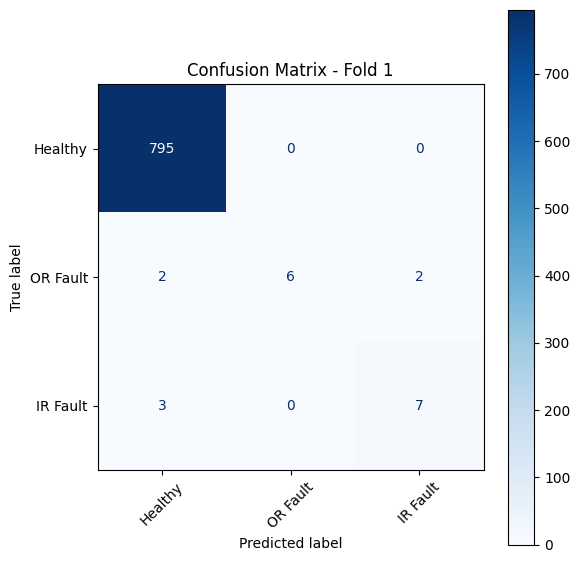

Saved confusion matrix for Fold 1 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram-2layer-CS/confusion_matrices/confusion_matrix_fold_1.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 184ms/step - accuracy: 0.9731 - loss: 0.0785 - val_accuracy: 0.9862 - val_loss: 0.0597
Epoch 27/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9772 - loss: 0.0309
Epoch 27: val_accuracy improved from 0.98618 to 0.98771, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram-2layer-CS/best_model_fold_2.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 0.9772 - loss: 0.0308 - val_accuracy: 0.9877 - val_loss: 0.0523
Epoch 28/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9901 - loss: 0.0190
Epoch 28: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 177ms/step - accuracy: 0.9901 - loss: 0.0190 - val_accuracy: 0.9877 - val_loss: 0.0564
Epoch 29/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9940 - loss: 0.0109
Epoch 29: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step - accuracy: 0.9940 - loss: 0.0109 - val_accuracy: 0.9877 - val_loss: 0.0579
Epoch 30/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9952 - loss: 0.0111
Epoch 30: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 178ms/step - accuracy: 0.9953 - loss: 0.0111 - val_accuracy: 0.9862 - val_loss: 0.0624
Epoch 31/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9949 - loss: 0.0079
Epoch 31: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 184ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.9892 - val_loss: 0.0625
Epoch 36/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9985 - loss: 0.0031
Epoch 36: val_accuracy did not improve from 0.98925
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 196ms/step - accuracy: 0.9985 - loss: 0.0031 - val_accuracy: 0.9892 - val_loss: 0.0628
Epoch 37/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 1.0000 - loss: 0.0018
Epoch 37: val_accuracy improved from 0.98925 to 0.99078, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram-2layer-CS/best_model_fold_2.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 209ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9908 - val_loss: 0.0638
Epoch 38/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 1.0000 - loss: 0.0026
Epoch 38: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 18s 219ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.9892 - val_loss: 0.0623
Epoch 39/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 1.0000 - loss: 0.0021
Epoch 39: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 193ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9908 - val_loss: 0.0624
Epoch 40/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 1.0000 - loss: 0.0014
Epoch 40: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 187ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9892 - val_loss: 0.0632
Epoch 41/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9998 - loss: 9.7539e-04
Epoch 41: val_ac

82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 239ms/step - accuracy: 0.9991 - loss: 0.0018 - val_accuracy: 0.9923 - val_loss: 0.0643
Epoch 43/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 1.0000 - loss: 7.5926e-04
Epoch 43: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 209ms/step - accuracy: 1.0000 - loss: 7.5912e-04 - val_accuracy: 0.9923 - val_loss: 0.0651
Epoch 44/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 1.0000 - loss: 0.0010
Epoch 44: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 199ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9923 - val_loss: 0.0654
Epoch 45/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 1.0000 - loss: 6.7506e-04
Epoch 45: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 195ms/step - accuracy: 1.0000 - loss: 6.7329e-04 - val_accuracy: 0.9923 - val_loss: 0.0659
Epoch 46/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 1.0000 - loss: 6.6656e-04


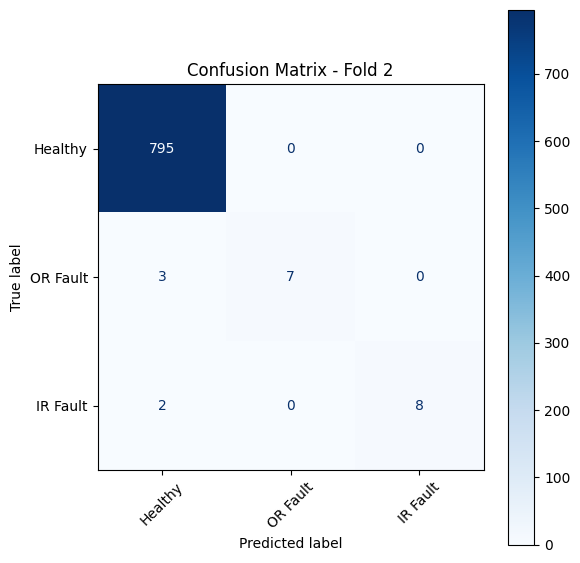

Saved confusion matrix for Fold 2 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram-2layer-CS/confusion_matrices/confusion_matrix_fold_2.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 192ms/step - accuracy: 0.6252 - loss: 1.0770 - val_accuracy: 0.9754 - val_loss: 0.1582
Epoch 3/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7362 - loss: 0.9067
Epoch 3: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 193ms/step - accuracy: 0.7369 - loss: 0.9044 - val_accuracy: 0.9754 - val_loss: 0.2005
Epoch 4/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.7580 - loss: 0.8121
Epoch 4: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 193ms/step - accuracy: 0.7586 - loss: 0.8098 - val_accuracy: 0.9754 - val_loss: 0.1825
Epoch 5/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.8033 - loss: 0.5352
Epoch 5: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 187ms/step - accuracy: 0.8038 - loss: 0.5343 - val_accuracy: 0.9754 - val_loss: 0.1527
Epoch 6/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.7603 - loss: 0.7260
Epoch 6: val_accuracy impro

82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step - accuracy: 0.7610 - loss: 0.7253 - val_accuracy: 0.9800 - val_loss: 0.0961
Epoch 7/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.8448 - loss: 0.5179
Epoch 7: val_accuracy did not improve from 0.98003
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 201ms/step - accuracy: 0.8453 - loss: 0.5161 - val_accuracy: 0.9754 - val_loss: 0.1611
Epoch 8/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9076 - loss: 0.2756
Epoch 8: val_accuracy did not improve from 0.98003
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 192ms/step - accuracy: 0.9079 - loss: 0.2751 - val_accuracy: 0.9724 - val_loss: 0.1878
Epoch 9/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9361 - loss: 0.1530
Epoch 9: val_accuracy did not improve from 0.98003
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 185ms/step - accuracy: 0.9363 - loss: 0.1528 - val_accuracy: 0.5484 - val_loss: 1.2850
Epoch 10/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.8866 - loss: 0.3045
Epoch 10: val_accuracy did

82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 182ms/step - accuracy: 0.9713 - loss: 0.0626 - val_accuracy: 0.9908 - val_loss: 0.0639
Epoch 19/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9705 - loss: 0.0562
Epoch 19: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - accuracy: 0.9706 - loss: 0.0559 - val_accuracy: 0.9908 - val_loss: 0.0491
Epoch 20/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9915 - loss: 0.0149
Epoch 20: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 179ms/step - accuracy: 0.9915 - loss: 0.0149 - val_accuracy: 0.9816 - val_loss: 0.0504
Epoch 21/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9939 - loss: 0.0155
Epoch 21: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 185ms/step - accuracy: 0.9939 - loss: 0.0154 - val_accuracy: 0.9908 - val_loss: 0.0476
Epoch 22/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9941 - loss: 0.0196
Epoch 22: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.9923 - val_loss: 0.0451
Epoch 27/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 1.0000 - loss: 0.0036
Epoch 27: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 189ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 0.9908 - val_loss: 0.0439
Epoch 28/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 1.0000 - loss: 0.0014
Epoch 28: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9892 - val_loss: 0.0458
Epoch 29/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 1.0000 - loss: 0.0020
Epoch 29: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 193ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9892 - val_loss: 0.0448
Epoch 30/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 1.0000 - loss: 0.0017
Epoch 30: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 202ms/step - accuracy: 1.0000 - loss: 1.3021e-04 - val_accuracy: 0.9939 - val_loss: 0.0430
Epoch 54/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 1.0000 - loss: 1.7122e-04
Epoch 54: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 200ms/step - accuracy: 1.0000 - loss: 1.7121e-04 - val_accuracy: 0.9923 - val_loss: 0.0456
Epoch 55/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 1.0000 - loss: 9.1228e-05
Epoch 55: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 196ms/step - accuracy: 1.0000 - loss: 9.1250e-05 - val_accuracy: 0.9923 - val_loss: 0.0460
Epoch 56/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 1.0000 - loss: 2.0738e-04
Epoch 56: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 189ms/step - accuracy: 1.0000 - loss: 2.0985e-04 - val_accuracy: 0.9923 - val_loss: 0.0421
Epoch 57/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 1.0000 - loss:

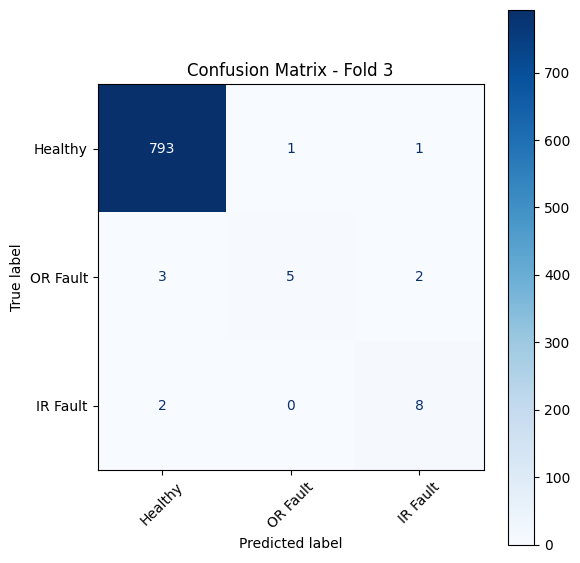

Saved confusion matrix for Fold 3 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram-2layer-CS/confusion_matrices/confusion_matrix_fold_3.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 168ms/step - accuracy: 0.8927 - loss: 0.3216 - val_accuracy: 0.9816 - val_loss: 0.1292
Epoch 8/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.8996 - loss: 0.3202
Epoch 8: val_accuracy did not improve from 0.98157
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 168ms/step - accuracy: 0.8999 - loss: 0.3196 - val_accuracy: 0.9724 - val_loss: 0.2146
Epoch 9/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9257 - loss: 0.2627
Epoch 9: val_accuracy did not improve from 0.98157
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 168ms/step - accuracy: 0.9258 - loss: 0.2618 - val_accuracy: 0.9693 - val_loss: 0.2026
Epoch 10/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9259 - loss: 0.3065
Epoch 10: val_accuracy did not improve from 0.98157
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 168ms/step - accuracy: 0.9259 - loss: 0.3056 - val_accuracy: 0.9278 - val_loss: 0.3405
Epoch 11/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9534 - loss: 0.1292
Epoch 11: val_accuracy d

82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 189ms/step - accuracy: 0.9942 - loss: 0.0120 - val_accuracy: 0.9831 - val_loss: 0.0954
Epoch 31/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9946 - loss: 0.0108
Epoch 31: val_accuracy did not improve from 0.98310
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 0.9946 - loss: 0.0107 - val_accuracy: 0.9831 - val_loss: 0.0951
Epoch 32/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9974 - loss: 0.0077
Epoch 32: val_accuracy did not improve from 0.98310
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step - accuracy: 0.9974 - loss: 0.0076 - val_accuracy: 0.9831 - val_loss: 0.0910
Epoch 33/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9970 - loss: 0.0079
Epoch 33: val_accuracy improved from 0.98310 to 0.98464, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram-2layer-CS/best_model_fold_4.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 167ms/step - accuracy: 0.9971 - loss: 0.0079 - val_accuracy: 0.9846 - val_loss: 0.0884
Epoch 34/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9990 - loss: 0.0041
Epoch 34: val_accuracy did not improve from 0.98464
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 0.9990 - loss: 0.0041 - val_accuracy: 0.9785 - val_loss: 0.0998
Epoch 35/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9989 - loss: 0.0034
Epoch 35: val_accuracy did not improve from 0.98464
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.9989 - loss: 0.0033 - val_accuracy: 0.9754 - val_loss: 0.1009
Epoch 36/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 1.0000 - loss: 0.0017
Epoch 36: val_accuracy did not improve from 0.98464
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9831 - val_loss: 0.0830
Epoch 37/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9988 - loss: 0.0025
Epoch 37: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.9862 - val_loss: 0.0904
Epoch 39/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 1.0000 - loss: 0.0018
Epoch 39: val_accuracy did not improve from 0.98618
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 185ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.7542 - val_loss: 1.1150
Epoch 40/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 1.0000 - loss: 8.9436e-04
Epoch 40: val_accuracy did not improve from 0.98618
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 1.0000 - loss: 8.9964e-04 - val_accuracy: 0.9677 - val_loss: 0.1371
Epoch 41/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 1.0000 - loss: 0.0014
Epoch 41: val_accuracy did not improve from 0.98618
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 167ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9846 - val_loss: 0.0950
Epoch 42/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9989 - loss: 0.0012
Epoch 42: va

82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 184ms/step - accuracy: 1.0000 - loss: 2.6125e-04 - val_accuracy: 0.9877 - val_loss: 0.1027
Epoch 57/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 1.0000 - loss: 3.5136e-04
Epoch 57: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 1.0000 - loss: 3.5218e-04 - val_accuracy: 0.5161 - val_loss: 3.7552
Epoch 58/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 1.0000 - loss: 3.2014e-04
Epoch 58: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 184ms/step - accuracy: 1.0000 - loss: 3.1981e-04 - val_accuracy: 0.9693 - val_loss: 0.1689
Epoch 59/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 1.0000 - loss: 3.1898e-04
Epoch 59: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 185ms/step - accuracy: 1.0000 - loss: 3.2132e-04 - val_accuracy: 0.9831 - val_loss: 0.1104
Epoch 60/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 1.0000 - loss:

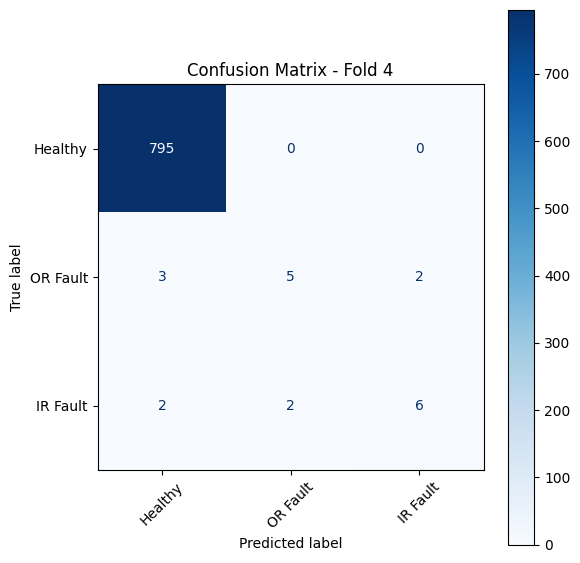

Saved confusion matrix for Fold 4 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram-2layer-CS/confusion_matrices/confusion_matrix_fold_4.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

Epoch 1/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.4419 - loss: 1.3588
Epoch 1: val_accuracy improved from -inf to 0.97542, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram-2layer-CS/best_model_fold_5.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.4428 - loss: 1.3570 - val_accuracy: 0.9754 - val_loss: 0.6359
Epoch 2/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.5521 - loss: 1.1127
Epoch 2: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.5533 - loss: 1.1110 - val_accuracy: 0.9754 - val_loss: 0.1355
Epoch 3/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.7363 - loss: 0.8126
Epoch 3: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 181ms/step - accuracy: 0.7364 - loss: 0.8119 - val_accuracy: 0.9754 - val_loss: 0.1809
Epoch 4/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.7119 - loss: 0.8361
Epoch 4: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 182ms/step - accuracy: 0.7124 - loss: 0.8347 - val_accuracy: 0.9754 - val_loss: 0.2936
Epoch 5/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.7779 - loss: 0.6090
Epoch 5: val_accuracy did n

82/82 ━━━━━━━━━━━━━━━━━━━━ 18s 220ms/step - accuracy: 0.9673 - loss: 0.0551 - val_accuracy: 0.9800 - val_loss: 0.0966
Epoch 22/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9600 - loss: 0.0976
Epoch 22: val_accuracy did not improve from 0.98003
82/82 ━━━━━━━━━━━━━━━━━━━━ 18s 216ms/step - accuracy: 0.9596 - loss: 0.0982 - val_accuracy: 0.0246 - val_loss: 9.6355
Epoch 23/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.8828 - loss: 0.2561
Epoch 23: val_accuracy did not improve from 0.98003
82/82 ━━━━━━━━━━━━━━━━━━━━ 18s 219ms/step - accuracy: 0.8823 - loss: 0.2573 - val_accuracy: 0.9355 - val_loss: 0.2070
Epoch 24/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.8844 - loss: 0.3980
Epoch 24: val_accuracy did not improve from 0.98003
82/82 ━━━━━━━━━━━━━━━━━━━━ 18s 215ms/step - accuracy: 0.8844 - loss: 0.3978 - val_accuracy: 0.9754 - val_loss: 0.1483
Epoch 25/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.8602 - loss: 0.2896
Epoch 25: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 206ms/step - accuracy: 0.8606 - loss: 0.2884 - val_accuracy: 0.9892 - val_loss: 0.0621
Epoch 26/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9680 - loss: 0.0418
Epoch 26: val_accuracy did not improve from 0.98925
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 0.9681 - loss: 0.0416 - val_accuracy: 0.9892 - val_loss: 0.0611
Epoch 27/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9862 - loss: 0.0292
Epoch 27: val_accuracy did not improve from 0.98925
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 0.9863 - loss: 0.0291 - val_accuracy: 0.9831 - val_loss: 0.0547
Epoch 28/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9926 - loss: 0.0132
Epoch 28: val_accuracy did not improve from 0.98925
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 0.9926 - loss: 0.0132 - val_accuracy: 0.9862 - val_loss: 0.0520
Epoch 29/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9957 - loss: 0.0077
Epoch 29: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - accuracy: 1.0000 - loss: 7.7112e-04 - val_accuracy: 0.9908 - val_loss: 0.0468
Epoch 43/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 1.0000 - loss: 5.7382e-04
Epoch 43: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 190ms/step - accuracy: 1.0000 - loss: 5.7232e-04 - val_accuracy: 0.9877 - val_loss: 0.0547
Epoch 44/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9996 - loss: 0.0024
Epoch 44: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 213ms/step - accuracy: 0.9996 - loss: 0.0024 - val_accuracy: 0.9877 - val_loss: 0.0506
Epoch 45/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 1.0000 - loss: 4.5972e-04
Epoch 45: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 194ms/step - accuracy: 1.0000 - loss: 4.6086e-04 - val_accuracy: 0.9908 - val_loss: 0.0474
Epoch 46/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 1.0000 - loss: 5.0374e

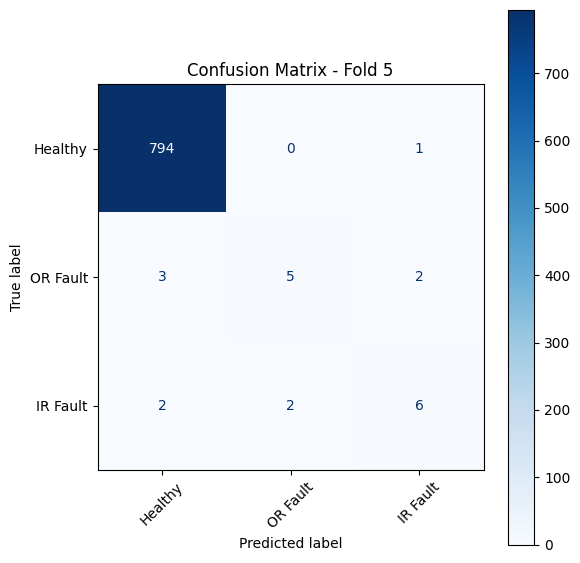

Saved confusion matrix for Fold 5 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram-2layer-CS/confusion_matrices/confusion_matrix_fold_5.png
Total Computation Time: 7780.45 seconds (129.67 minutes)


In [15]:
# Training with k-fold validation
kSplits = 5
accuracy_2D = []
precision_2D = []
recall_2D = []
f1_2D = []
log_loss_2D = []
balanced_accuracy_2D = []
precision_2D_macro = []
recall_2D_macro = []
f1_2D_macro = []
accuracy_2D_test = []
precision_2D_test = []
recall_2D_test = []
log_loss_2D_test = []
f1_2D_test = []
precision_2D_test_macro = []
recall_2D_test_macro = []
f1_2D_test_macro = []
balanced_accuracy_2D_test = []
# accuracy_val = []

foldername = "Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram-2layer-CS/"

condition_map = {
    0: "Healthy",
    1: "OR Fault",
    2: "IR Fault"
}

early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
start_time = time.time()
y_labels = np.argmax(y_train_positional_split, axis=1)

kfold = StratifiedKFold(n_splits=kSplits, random_state=32, shuffle=True)

for fold, (train_idx, test_idx) in enumerate(kfold.split(X_2D_train, y_labels)):

    Classification_2D = CNN_2D()

    checkpoint_filepath = os.path.join(foldername, f"best_model_fold_{fold+1}.h5")
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    )

    Classification_2D.model.fit(X_2D_train[train_idx], y_train_positional_split[train_idx],
                                validation_data=(X_2D_train[test_idx], y_train_positional_split[test_idx]),
                                epochs=200, callbacks=[early_stopping, checkpoint], verbose=1,class_weight=class_weights)

    print(f"Best model for Fold {fold+1} saved to: {checkpoint_filepath}")

    # Train set metrics
    y_pred_proba_train = Classification_2D.model.predict(X_2D_train)
    y_pred_train = np.argmax(y_pred_proba_train, axis=1)
    y_true_train = np.argmax(y_train_positional_split, axis=1)

    accuracy_2D.append(accuracy_score(y_true_train, y_pred_train))
    precision_2D.append(precision_score(y_true_train, y_pred_train, average='weighted'))
    recall_2D.append(recall_score(y_true_train, y_pred_train, average='weighted'))
    f1_2D.append(f1_score(y_true_train, y_pred_train, average='weighted'))
    log_loss_2D.append(log_loss(y_true_train, y_pred_proba_train))
    balanced_accuracy_2D.append(balanced_accuracy_score(y_true_train, y_pred_train))
    precision_2D_macro.append(precision_score(y_true_train, y_pred_train, average='macro'))
    recall_2D_macro.append(recall_score(y_true_train, y_pred_train, average='macro'))
    f1_2D_macro.append(f1_score(y_true_train, y_pred_train, average='macro'))

    # Test set metrics
    y_pred_proba_test = Classification_2D.model.predict(X_2D_test)
    y_pred_test = np.argmax(y_pred_proba_test, axis=1)
    y_true_test = np.argmax(y_test_positional_split, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_true_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[condition_map[i] for i in range(3)])
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
    plt.title(f'Confusion Matrix - Fold {fold + 1}')
    plt.grid(False)
    plt.tight_layout()

    # Save confusion matrix
    save_dir = os.path.join(foldername, "confusion_matrices")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"confusion_matrix_fold_{fold + 1}.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved confusion matrix for Fold {fold + 1} at: {save_path}")

    # accuracy_val.append(accuracy_score(X_2D_train[test_idx], y_train_positional_split[test_idx]))
    accuracy_2D_test.append(accuracy_score(y_true_test, y_pred_test))
    precision_2D_test.append(precision_score(y_true_test, y_pred_test, average='weighted'))
    recall_2D_test.append(recall_score(y_true_test, y_pred_test, average='weighted'))
    f1_2D_test.append(f1_score(y_true_test, y_pred_test, average='weighted'))
    precision_2D_test_macro.append(precision_score(y_true_test, y_pred_test, average='macro'))
    recall_2D_test_macro.append(recall_score(y_true_test, y_pred_test, average='macro'))
    f1_2D_test_macro.append(f1_score(y_true_test, y_pred_test, average='macro'))
    log_loss_2D_test.append(log_loss(y_true_test, y_pred_proba_test))
    balanced_accuracy_2D_test.append(balanced_accuracy_score(y_true_test, y_pred_test))

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total Computation Time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")


In [21]:
# Aggregated metrics
CNN_2D_train_accuracy = np.mean(accuracy_2D) * 100
CNN_2D_test_accuracy = np.mean(accuracy_2D_test) * 100
CNN_2D_train_precision = np.mean(precision_2D) * 100
CNN_2D_test_precision = np.mean(precision_2D_test) * 100
CNN_2D_train_recall = np.mean(recall_2D) * 100
CNN_2D_test_recall = np.mean(recall_2D_test) * 100
CNN_2D_train_f1 = np.mean(f1_2D) * 100
CNN_2D_test_f1 = np.mean(f1_2D_test) * 100
CNN_2D_train_precision_macro = np.mean(precision_2D_macro) * 100
CNN_2D_train_recall_macro = np.mean(recall_2D_macro) * 100
CNN_2D_train_f1_macro = np.mean(f1_2D_macro) * 100
CNN_2D_test_precision_macro = np.mean(precision_2D_test_macro) * 100
CNN_2D_test_recall_macro = np.mean(recall_2D_test_macro) * 100
CNN_2D_test_f1_macro = np.mean(f1_2D_test_macro) * 100
CNN_2D_train_log_loss = np.mean(log_loss_2D)
CNN_2D_test_log_loss = np.mean(log_loss_2D_test)
CNN_2D_train_balanced_accuracy = np.mean(balanced_accuracy_2D) * 100
CNN_2D_test_balanced_accuracy = np.mean(balanced_accuracy_2D_test) * 100
# CNN_2D_val_accuracy = np.mean(accuracy_val) * 100

# Print metrics
print(f"Train Accuracy: {CNN_2D_train_accuracy:.2f}%")
print(f"Test Accuracy: {CNN_2D_test_accuracy:.2f}%")
print(f"Train Precision: {CNN_2D_train_precision:.2f}%")
print(f"Test Precision: {CNN_2D_test_precision:.2f}%")
print(f"Train Recall: {CNN_2D_train_recall:.2f}%")
print(f"Test Recall: {CNN_2D_test_recall:.2f}%")
print(f"Train F1: {CNN_2D_train_f1:.2f}%")
print(f"Test F1: {CNN_2D_test_f1:.2f}%")
print(f"Train Log Loss: {CNN_2D_train_log_loss:.4f}")
print(f"Test Log Loss: {CNN_2D_test_log_loss:.4f}")
print(f"Train Balanced Accuracy: {CNN_2D_train_balanced_accuracy:.2f}%")
print(f"Test Balanced Accuracy: {CNN_2D_test_balanced_accuracy:.2f}%")

print(f"Train Precision (Macro): {CNN_2D_train_precision_macro:.2f}%")
print(f"Train Recall (Macro): {CNN_2D_train_recall_macro:.2f}%")
print(f"Train F1 Score (Macro): {CNN_2D_train_f1_macro:.2f}%")

print(f"Test Precision (Macro): {CNN_2D_test_precision_macro:.2f}%")
print(f"Test Recall (Macro): {CNN_2D_test_recall_macro:.2f}%")
print(f"Test F1 Score (Macro): {CNN_2D_test_f1_macro:.2f}%")

# print(f"CNN_2D_val_accuracy: {CNN_2D_val_accuracy:.2f}%")


Train Accuracy: 99.81%
Test Accuracy: 99.02%
Train Precision: 99.81%
Test Precision: 98.94%
Train Recall: 99.81%
Test Recall: 99.02%
Train F1: 99.81%
Test F1: 98.94%
Train Log Loss: 0.0142
Test Log Loss: 0.0840
Train Balanced Accuracy: 95.33%
Test Balanced Accuracy: 75.31%
Train Precision (Macro): 98.40%
Train Recall (Macro): 95.33%
Train F1 Score (Macro): 96.80%
Test Precision (Macro): 87.68%
Test Recall (Macro): 75.31%
Test F1 Score (Macro): 80.29%


102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step


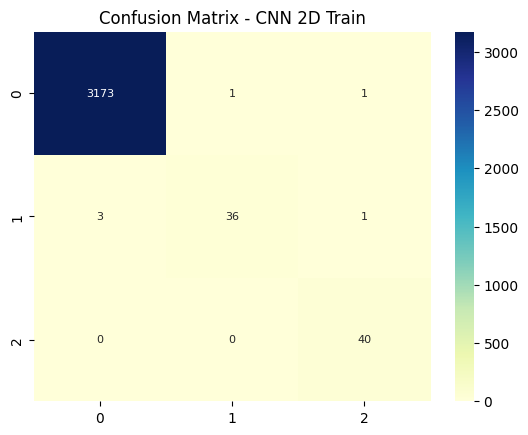

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


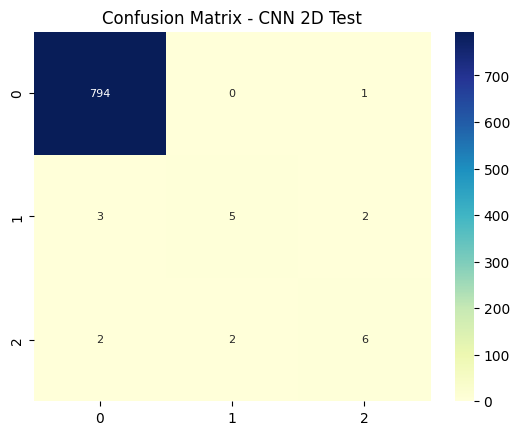

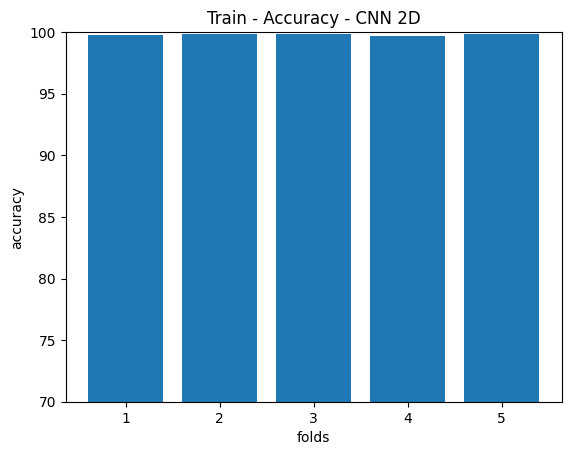

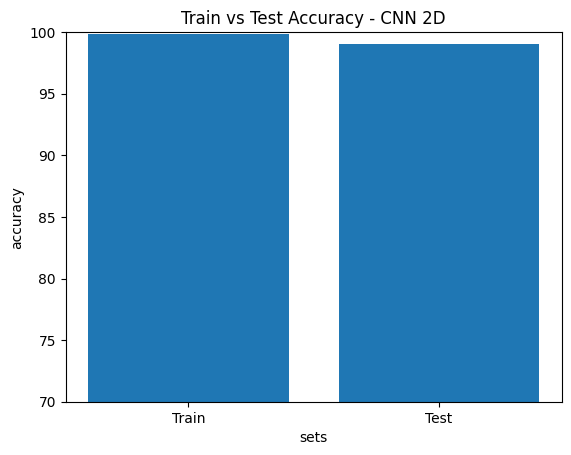

In [22]:
# Confusion Matrix Calculation
def ConfusionMatrix(Model, X, y):
    y_pred_proba = Model.model.predict(X)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y, axis=1)
    return confusion_matrix(y_true, y_pred)

# Plot results - CNN 2D
plt.figure(1)
plt.title('Confusion Matrix - CNN 2D Train')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_train, y_train_positional_split),
            annot=True, fmt='d', annot_kws={"fontsize": 8}, cmap="YlGnBu")
plt.show()

plt.figure(2)
plt.title('Confusion Matrix - CNN 2D Test')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_test, y_test_positional_split),
            annot=True, fmt='d', annot_kws={"fontsize": 8}, cmap="YlGnBu")
plt.show()

plt.figure(3)
plt.title('Train - Accuracy - CNN 2D')
plt.bar(np.arange(1, kSplits + 1), [i * 100 for i in accuracy_2D])
plt.ylabel('accuracy')
plt.xlabel('folds')
plt.ylim([70, 100])
plt.show()

plt.figure(4)
plt.title('Train vs Test Accuracy - CNN 2D')
plt.bar([1, 2], [CNN_2D_train_accuracy, CNN_2D_test_accuracy])
plt.ylabel('accuracy')
plt.xlabel('sets')
plt.xticks([1, 2], ['Train', 'Test'])
plt.ylim([70, 100])
plt.show()


In [18]:




# Create DataFrame from per-fold metrics
metrics_df = pd.DataFrame({
    'Fold': np.arange(1, 5 + 1),
    
    'Train Accuracy (%)': np.array(accuracy_2D) * 100,
    'Test Accuracy (%)': np.array(accuracy_2D_test) * 100,

    'Train Precision (%)': np.array(precision_2D) * 100,
    'Test Precision (%)': np.array(precision_2D_test) * 100,

    'Train Recall (%)': np.array(recall_2D) * 100,
    'Test Recall (%)': np.array(recall_2D_test) * 100,

    'Train F1-score (%)': np.array(f1_2D) * 100,
    'Test F1-score (%)': np.array(f1_2D_test) * 100,

    'Train Precision-Macro (%)': np.array(precision_2D_macro) * 100,
    'Test Precision-Macro (%)': np.array(precision_2D_test_macro) * 100,

    'Train Recall-Macro (%)': np.array(recall_2D_macro) * 100,
    'Test Recall-Macro (%)': np.array(recall_2D_test_macro) * 100,

    'Train F1-score (%)': np.array(f1_2D_macro) * 100,
    'Test F1-score (%)': np.array(f1_2D_test_macro) * 100,

    'Train Log Loss': log_loss_2D,
    'Test Log Loss': log_loss_2D_test,

    'Train Balanced Accuracy (%)': np.array(balanced_accuracy_2D) * 100,
    'Test Balanced Accuracy (%)': np.array(balanced_accuracy_2D_test) * 100,
})

metrics_df.round(2)
# Sort by highest Test F1-score (%)
# sorted_df = metrics_df.sort_values(by='Test Balanced Accuracy (%)', ascending=False)
# sorted_df.round(2)

,Fold,Train Accuracy (%),Test Accuracy (%),Train Precision (%),Test Precision (%),Train Recall (%),Test Recall (%),Train F1-score (%),Test F1-score (%),Train Precision-Macro (%),Test Precision-Macro (%),Train Recall-Macro (%),Test Recall-Macro (%),Train Log Loss,Test Log Loss,Train Balanced Accuracy (%),Test Balanced Accuracy (%)
0,1,99.78,99.14,99.78,99.12,99.78,99.14,96.11,82.79,98.19,92.38,94.17,76.67,0.02,0.08,94.17,76.67
1,2,99.85,99.39,99.84,99.39,99.85,99.39,97.01,90.31,98.24,99.79,95.83,83.33,0.01,0.06,95.83,83.33
2,3,99.88,98.90,99.88,98.85,99.88,98.90,98.27,79.42,99.96,85.14,96.67,76.58,0.01,0.09,96.67,76.58
3,4,99.72,98.90,99.72,98.73,99.72,98.90,95.62,75.06,98.12,81.93,93.32,70.00,0.02,0.12,93.32,70.00
4,5,99.82,98.77,99.82,98.63,99.82,98.77,97.00,73.87,97.48,79.16,96.65,69.96,0.01,0.08,96.65,69.96



Evaluating model: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram-2layer-CS/best_model_fold_1.h5


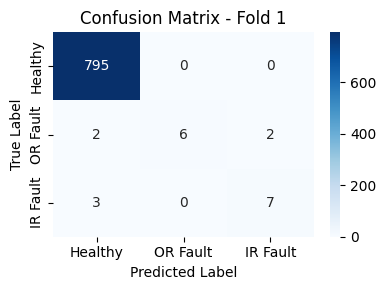


Evaluating model: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram-2layer-CS/best_model_fold_2.h5


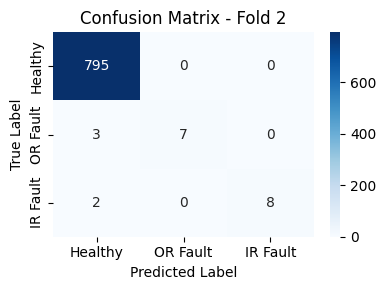


Evaluating model: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram-2layer-CS/best_model_fold_3.h5


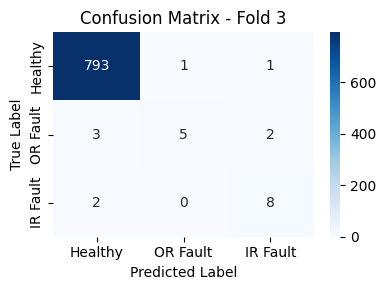


Evaluating model: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram-2layer-CS/best_model_fold_4.h5


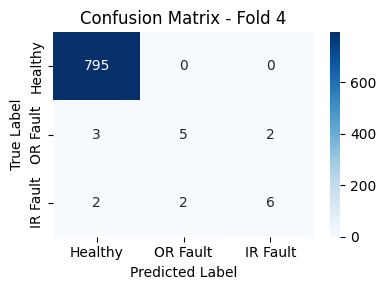


Evaluating model: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram-2layer-CS/best_model_fold_5.h5


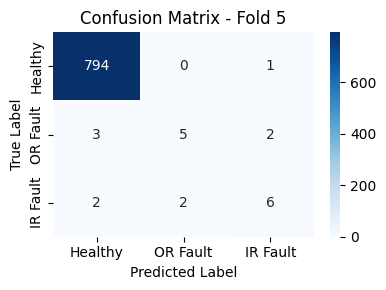


 Test Metrics Summary (Same Test Set Across All Models):


,Fold,Test Accuracy (%),Test Precision (%),Test Recall (%),Test F1-score (%),Test Precision (Macro) (%),Test Recall (Macro) (%),Test F1-score (Macro) (%),Test Log Loss,Test Balanced Accuracy (%)
0,1,99.14,99.12,99.14,99.06,92.38,76.67,82.79,0.08,76.67
1,2,99.39,99.39,99.39,99.34,99.79,83.33,90.31,0.06,83.33
2,3,98.90,98.85,98.90,98.82,85.14,76.58,79.42,0.09,76.58
3,4,98.90,98.73,98.90,98.78,81.93,70.00,75.06,0.12,70.00
4,5,98.77,98.63,98.77,98.68,79.16,69.96,73.87,0.08,69.96
5,Average,99.02,98.94,99.02,98.94,87.68,75.31,80.29,0.09,75.31


In [27]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, log_loss, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

foldername = "Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram-2layer-CS/"
class_names = ['Healthy', 'OR Fault', 'IR Fault']
# Set paths
num_folds = 5  # Assuming models are: best_model_fold_1.h5 to _5.h5

# Use these test variables from your data pipeline
# Already loaded:
# X_test_split, y_test_positional_split

# Flatten labels
y_true = np.argmax(y_test_positional_split, axis=1)

# Containers
folds = []
accuracy_test = []
precision_test = []
recall_test = []
f1_test = []
precision_macro = []
recall_macro = []
f1_macro = []
log_loss_test = []
balanced_acc = []

# Loop through models
for fold in range(1, num_folds + 1):
    model_path = os.path.join(foldername, f"best_model_fold_{fold}.h5")
    print(f"\nEvaluating model: {model_path}")

    model = load_model(model_path)
  
    #test metrics
    y_pred_proba = model.predict(X_test_split, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    folds.append(fold)
    accuracy_test.append(accuracy_score(y_true, y_pred) * 100)
    precision_test.append(precision_score(y_true, y_pred, average='weighted') * 100)
    recall_test.append(recall_score(y_true, y_pred, average='weighted') * 100)
    f1_test.append(f1_score(y_true, y_pred, average='weighted') * 100)

    precision_macro.append(precision_score(y_true, y_pred, average='macro') * 100)
    recall_macro.append(recall_score(y_true, y_pred, average='macro') * 100)
    f1_macro.append(f1_score(y_true, y_pred, average='macro') * 100)

    log_loss_test.append(log_loss(y_true, y_pred_proba))
    balanced_acc.append(balanced_accuracy_score(y_true, y_pred) * 100)
      
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()
    

# Create and print metrics DataFrame
metrics_df = pd.DataFrame({
    'Fold': folds,
    'Test Accuracy (%)': accuracy_test,
    'Test Precision (%)': precision_test,
    'Test Recall (%)': recall_test,
    'Test F1-score (%)': f1_test,
    'Test Precision (Macro) (%)': precision_macro,
    'Test Recall (Macro) (%)': recall_macro,
    'Test F1-score (Macro) (%)': f1_macro,
    'Test Log Loss': log_loss_test,
    'Test Balanced Accuracy (%)': balanced_acc,
}).round(2)

# Compute average metrics across folds
average_metrics = metrics_df.mean(numeric_only=True).round(2)

# Safely assign 'Average' to the Fold column (overwrite if it exists)
average_row = average_metrics.to_frame().T
average_row['Fold'] = 'Average'

# Move 'Fold' to the front if needed
cols = ['Fold'] + [col for col in average_row.columns if col != 'Fold']
average_row = average_row[cols]

# Append to original metrics_df
metrics_df = pd.concat([metrics_df, average_row], ignore_index=True)

print("\n Test Metrics Summary (Same Test Set Across All Models):")
metrics_df
